**Wisconsin Breast Cancer Database**

Datos:

| Columna | Explicación |
|---|---|
| id | Número de identificación de la muestra |
| clump_thickness | Grosor del grupo de células |
| uniformity_cell_size | Qué tan parecido es el tamaño entre células |
| uniformity_cell_shape | Qué tan parecida es la forma entre células |
| marginal_adhesion | Qué tanto se mantienen unidas las células |
| single_epithelial_cell_size | Tamaño de las células epiteliales individuales |
| bare_nuclei | Núcleos sin citoplasma alrededor |
| bland_chromatin | Textura de la cromatina del núcleo |
| normal_nucleoli | Qué tan visibles son los nucléolos |
| mitoses | Frecuencia de división celular |
| class | Diagnóstico: 2 = benigno, 4 = maligno. Variable objetivo |

Cita: Wolberg, W. H., & Mangasarian, O. L. (1990). Multisurface method of pattern separation for medical diagnosis applied to breast cytology. Proceedings of the National Academy of Sciences, 87, 9193–9196.

In [1]:
# importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import imblearn

print("numpy     ", np.__version__)
print("pandas    ", pd.__version__)
print("matplotlib", __import__("matplotlib").__version__)
print("seaborn   ", sns.__version__)
print("sklearn   ", sklearn.__version__)
print("imblearn  ", imblearn.__version__)

numpy      2.1.3
pandas     2.2.3
matplotlib 3.10.0
seaborn    0.13.2
sklearn    1.6.1
imblearn   0.14.2


El archivo .data no trae encabezados, así que los nombres de las columnas se asignan al cargarlo, siguiendo el orden de la documentación (.names).

In [2]:
# crear dataframe
columnas = ["id", "clump_thickness", "uniformity_cell_size",
            "uniformity_cell_shape", "marginal_adhesion",
            "single_epithelial_cell_size", "bare_nuclei",
            "bland_chromatin", "normal_nucleoli", "mitoses", "class"]

df = pd.read_csv("/content/drive/MyDrive/INTRODUCCIÓN A LA CIENCIA DE DATOS/practicas/Notebook Preprocesamiento/breast-cancer-wisconsin.data",header=None, names=columnas)
df

,id,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...
694,776715,3,1,1,1,3,2,1,1,1,2
695,841769,2,1,1,1,2,1,1,1,1,2
696,888820,5,10,10,3,7,3,8,10,2,4
697,897471,4,8,6,4,3,4,10,6,1,4


In [3]:
n_filas, n_columnas = df.shape
n_numericas = df.select_dtypes(include="number").shape[1]
n_no_numericas = df.select_dtypes(exclude="number").shape[1]

print(f"Registros:               {n_filas:>5}")
print(f"Atributos:               {n_columnas:>5}")
print(f"  numéricos:             {n_numericas:>5}")
print(f"  no numéricos:          {n_no_numericas:>5}")
print(f"Duplicados exactos:      {df.duplicated().sum():>5}")
print(f"Registros con faltantes: {df.isna().any(axis=1).sum():>5}")

Registros:                 699
Atributos:                  11
  numéricos:                10
  no numéricos:              1
Duplicados exactos:          8
Registros con faltantes:     0


1. Aparece una columna no numérica, aunque según la documentación todos los atributos van del 1 al 10. Hay que revisar cuál es y por qué.
2. No se detectan faltantes, pero la documentación dice que hay 16. Esto sugiere que los faltantes no vienen como NaN, sino con otro símbolo.
3. Hay 8 duplicados.

In [4]:
columnas_no_numericas = df.select_dtypes(exclude="number").columns
for columna in columnas_no_numericas:
    print(f"\n - {columna} -")
    print(df[columna].unique())


 - bare_nuclei -
['1' '10' '2' '4' '3' '9' '7' '?' '5' '8' '6']


La única columna no numérica es 'bare_nuclei'. Sus valores son los números del 1 al 10, pero guardados como texto, porque la columna también tiene el símbolo '?'.

In [5]:
print((df == "?").sum()[(df == "?").sum() > 0])

bare_nuclei    16
dtype: int64


El símbolo '?' aparece 16 veces, justo el número de faltantes que reporta la documentación. Entonces '?' es la forma en que se marcan los datos faltantes.

**¿Los faltantes se concentran en alguna clase?**

In [6]:
faltantes = df["bare_nuclei"].eq("?")
faltantes_clase = (
    df.assign(faltante=faltantes)
    .groupby("class")["faltante"]
    .agg(registros="size", faltantes="sum", porcentaje="mean"))
faltantes_clase["porcentaje"] = (faltantes_clase["porcentaje"] * 100).round(1)
faltantes_clase

,registros,faltantes,porcentaje
class,,,
2,458,14,3.1
4,241,2,0.8


Los faltantes son pocos en ambas clases, aunque aparecen más en benignos (3.1 %) que en malignos (0.8 %). Al ser pocos casos, no parece un patrón.
Además, las clases estan desbalanceadas y hay mayores faltantes en la clase que tiene más instancias, por lo que creo que imputarlos no será una mala desición.

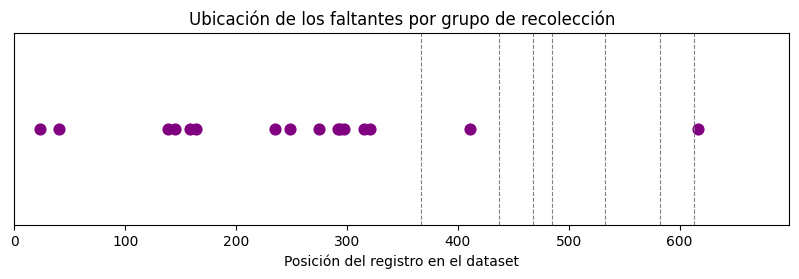

In [7]:
tamanos_grupo = [367, 70, 31, 17, 48, 49, 31, 86]
limites_grupo = np.cumsum(tamanos_grupo)
fig, ax = plt.subplots(figsize=(10, 2.5))
ax.scatter(df.index[faltantes], np.zeros(faltantes.sum()),
           s=60, color="purple")
for limite in limites_grupo[:-1]:
    ax.axvline(limite, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlim(0, len(df))
ax.set_yticks([])
ax.set_xlabel("Posición del registro en el dataset")
ax.set_title("Ubicación de los faltantes por grupo de recolección")
plt.show()

Las líneas punteadas marcan dónde termina cada grupo, según los tamaños de la documentación. La mayoría de los faltantes está en el primer grupo, que también es el más grande (367 registros). Por lo que creo que se respalda mi decisión de imputarlos.

**Duplicados**

In [8]:
print("Duplicados exactos:", df.duplicated().sum())

Duplicados exactos: 8


In [9]:
df[df.duplicated(keep=False)].sort_values("id")

,id,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
272,320675,3,3,5,2,3,10,7,1,1,4
267,320675,3,3,5,2,3,10,7,1,1,4
684,466906,1,1,1,1,2,1,1,1,1,2
683,466906,1,1,1,1,2,1,1,1,1,2
314,704097,1,1,1,1,1,1,2,1,1,2
338,704097,1,1,1,1,1,1,2,1,1,2
42,1100524,6,10,10,2,8,10,7,3,3,4
253,1100524,6,10,10,2,8,10,7,3,3,4
62,1116116,9,10,10,1,10,8,3,3,1,4
254,1116116,9,10,10,1,10,8,3,3,1,4


Son 8 parejas idénticas en todo, incluido el id. Algunas están en filas contiguas y otras lejanas. Según la documentación, el id es el número de la muestra, así que no debería repetirse.

In [10]:
print("id repetidos:", df["id"].duplicated().sum())

id repetidos: 54


Hay 54 id repetidos, muchos más que los 8 duplicados exactos. Entonces hay id que se repiten con valores distintos.

In [11]:
repetidos = df[df["id"].duplicated(keep=False)]
por_id = repetidos.groupby("id")
print("id distintos que se repiten:", por_id.ngroups)
print("Máximo de repeticiones de un id:", por_id.size().max())
print("id con clase distinta entre registros:",
      (por_id["class"].nunique() > 1).sum())

id distintos que se repiten: 46
Máximo de repeticiones de un id: 6
id con clase distinta entre registros: 4


Hay 4 id con clase distinta entre sus registros. Por lo que parece que el id no identifica una muestra, sino quizá a un paciente con varias muestras.

In [12]:
print("Duplicados sin considerar id:", df.drop(columns="id").duplicated(keep=False).sum())

Duplicados sin considerar id: 284


Hay 284 registros idénticos si se ignora el id.

In [13]:
duplicados_sin_id = df.drop(columns="id").duplicated(keep=False)
duplicados_sin_id.groupby(df["class"]).sum()

,0
class,
2,278
4,6


Casi todos son benignos (278 contra 6 malignos). Con escalas del 1 al 10, que muestras distintas tengan los mismos valores es esperable, así que no se consideran duplicados.

**Valores feura de rango**

Según la documentación, los 9 atributos van del 1 al 10 y la clase solo puede ser 2 o 4.

In [14]:
df.describe().round(1)

,id,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bland_chromatin,normal_nucleoli,mitoses,class
count,699.0,699.0,699.0,699.0,699.0,699.0,699.0,699.0,699.0,699.0
mean,1071704.1,4.4,3.1,3.2,2.8,3.2,3.4,2.9,1.6,2.7
std,617095.7,2.8,3.1,3.0,2.9,2.2,2.4,3.1,1.7,1.0
min,61634.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0
25%,870688.5,2.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,2.0
50%,1171710.0,4.0,1.0,1.0,1.0,2.0,3.0,1.0,1.0,2.0
75%,1238298.0,6.0,5.0,5.0,4.0,4.0,5.0,4.0,1.0,4.0
max,13454352.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,4.0


In [15]:
print(df["class"].value_counts())

class
2    458
4    241
Name: count, dtype: int64


Todos los atributos numéricos tienen mínimo 1 y máximo 10, y la clase va de 2 a 4. No hay valores fuera de rango. 'bare_nuclei' no aparece en la tabla porque está guardada como texto, así que se revisa aparte.

In [16]:
print("bare_nuclei:", sorted(df["bare_nuclei"].unique()))

bare_nuclei: ['1', '10', '2', '3', '4', '5', '6', '7', '8', '9', '?']


'bare_nuclei' tiene los valores del 1 al 10 y el '?' ya identificado.

Antes del análisis univariado se convierte el '?' de 'bare_nuclei' a NaN y la columna a numérica, para poder graficarla junto con los demás atributos. La imputación se deja para la limpieza.

In [17]:
df["bare_nuclei"] = pd.to_numeric(df["bare_nuclei"].replace("?", np.nan))
print("Tipo:", df["bare_nuclei"].dtype)
print("Faltantes:", df["bare_nuclei"].isna().sum())

Tipo: float64
Faltantes: 16


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           699 non-null    int64  
 1   clump_thickness              699 non-null    int64  
 2   uniformity_cell_size         699 non-null    int64  
 3   uniformity_cell_shape        699 non-null    int64  
 4   marginal_adhesion            699 non-null    int64  
 5   single_epithelial_cell_size  699 non-null    int64  
 6   bare_nuclei                  683 non-null    float64
 7   bland_chromatin              699 non-null    int64  
 8   normal_nucleoli              699 non-null    int64  
 9   mitoses                      699 non-null    int64  
 10  class                        699 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 60.2 KB


Me genero duda que sea float64 y no int64, pero se debe al NaN.

**Análsis univariado**

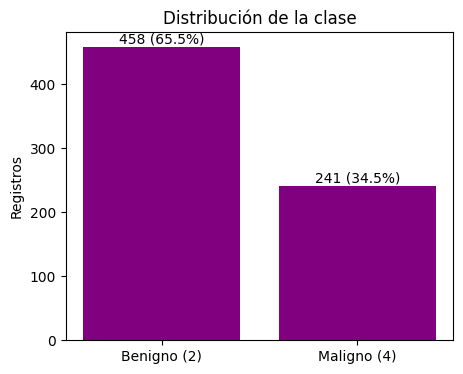

In [19]:
conteo_clase = df["class"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Benigno (2)", "Maligno (4)"], conteo_clase, color="purple")
for i, valor in enumerate(conteo_clase):
    ax.text(i, valor + 5, f"{valor} ({valor / len(df) * 100:.1f}%)", ha="center")
ax.set_ylabel("Registros")
ax.set_title("Distribución de la clase")
plt.show()

Las clases están desbalanceadas: 65.5 % benignos y 34.5 % malignos, casi dos a uno. Esto me sugiere implementar aumento de datos.

In [20]:
variables_ordinales = ["clump_thickness", "uniformity_cell_size",
                       "uniformity_cell_shape", "marginal_adhesion",
                       "single_epithelial_cell_size", "bare_nuclei",
                       "bland_chromatin", "normal_nucleoli", "mitoses"]
variable_objetivo = "class"

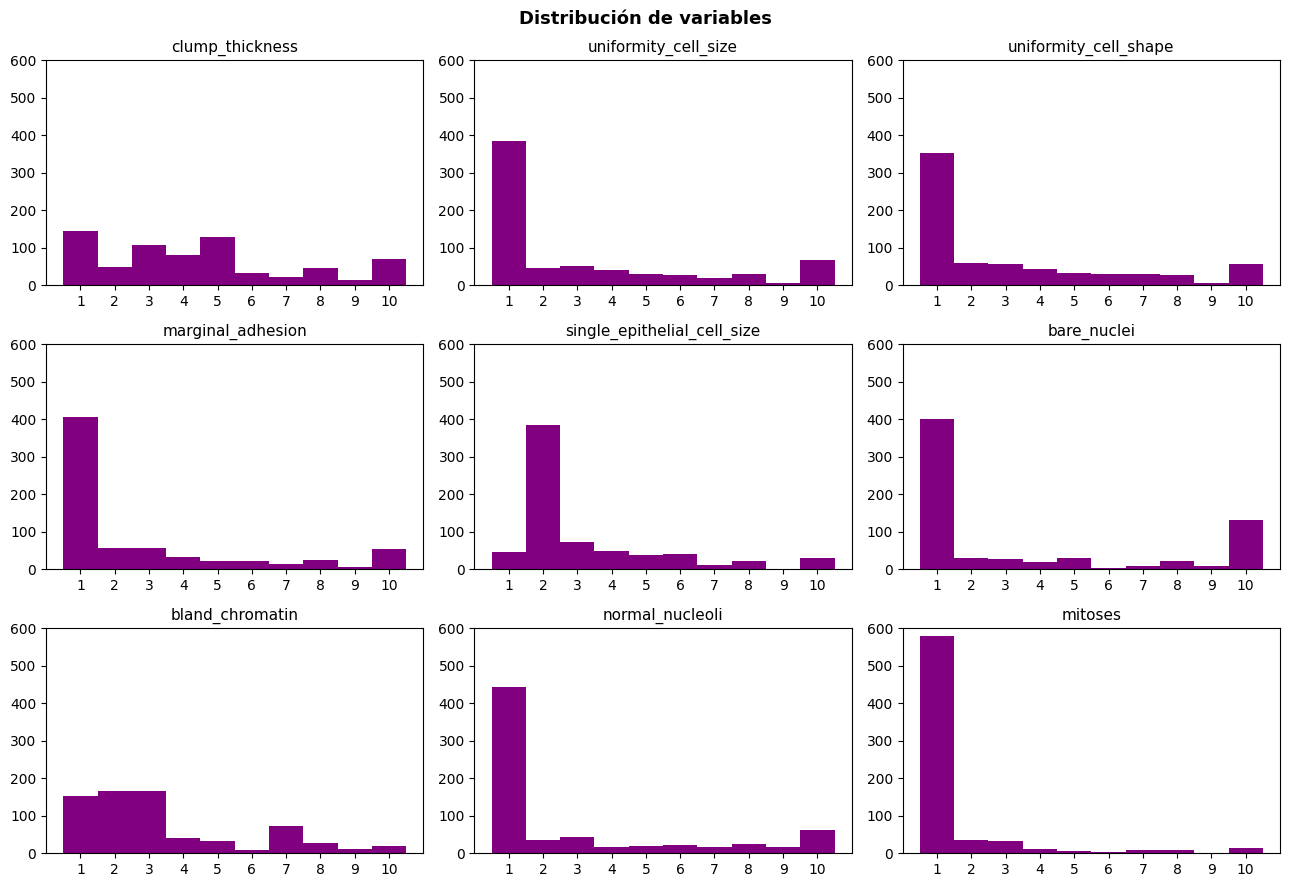

In [38]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for ax, columna in zip(axes.ravel(), variables_ordinales):
    ax.hist(df[columna].dropna(), bins=np.arange(0.5, 11.5, 1), color="purple")
    ax.set_title(columna, fontsize=11)
    ax.set_xticks(range(1, 11))
    ax.set_ylim(0, 600)
fig.suptitle("Distribución de variables",
             fontsize=13, color="black", fontweight="bold")
plt.tight_layout()
plt.show()

  Todos los atributos se cargan hacia la izquierda, la mayoría en el valor 1. "clump_thickness" no sigue exactamente dicho patrón, pero aún se observa sesgo a la izquierda.

**Análsis bivariado**

En el análisis univariado la mayoría de los atributos se cargaba hacia el 1 y varios tenían un segundo pico en 10. ¿Esos dos grupos corresponden a las clases?

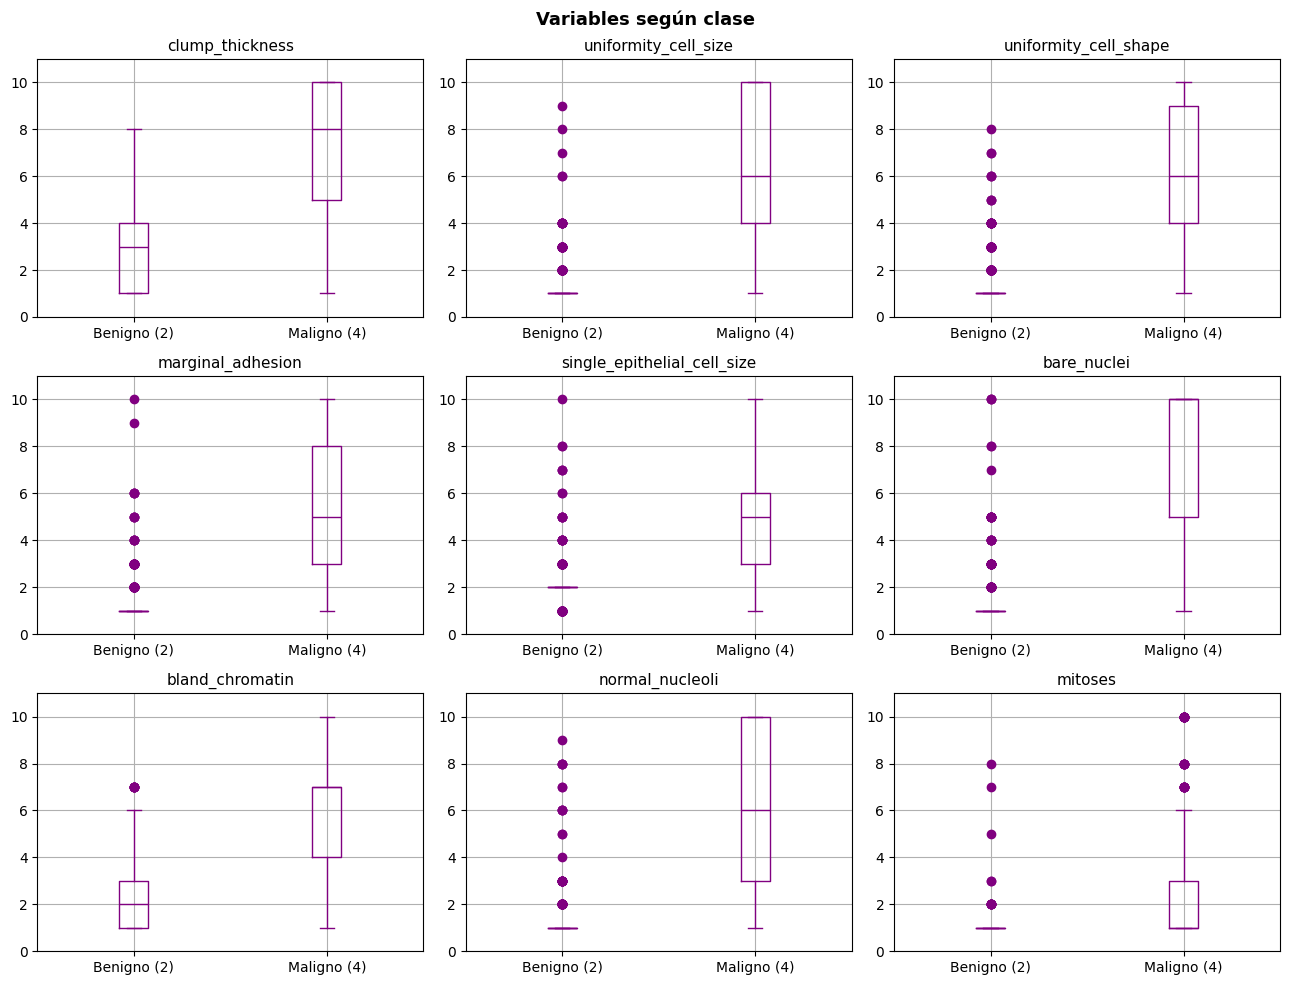

In [22]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, columna in zip(axes.ravel(), variables_ordinales):
    df.boxplot(
        column=columna,
        by="class",
        ax=ax,
        boxprops=dict(color="purple"),
        medianprops=dict(color="purple"),
        whiskerprops=dict(color="purple"),
        capprops=dict(color="purple"),
        flierprops=dict(
            markeredgecolor="purple",
            markerfacecolor="purple")
    )
    ax.set_title(columna, fontsize=11)
    ax.set_xlabel("")
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Benigno (2)", "Maligno (4)"])
    ax.set_ylim(0, 11)
fig.suptitle("Variables según clase",
             fontsize=13, color="black", fontweight="bold")
plt.tight_layout()
plt.show()

En casi todos los atributos los benignos se concentran en valores bajos y los malignos en valores altos. En benignos, la caja de varios atributos queda aplastada en 1, y lo que se ve arriba son puntos atípicos.

**Análisis multivariado**

Se observó que casi todas las variables suben juntas en los malignos, ¿qué tan relacionadas están entre sí?

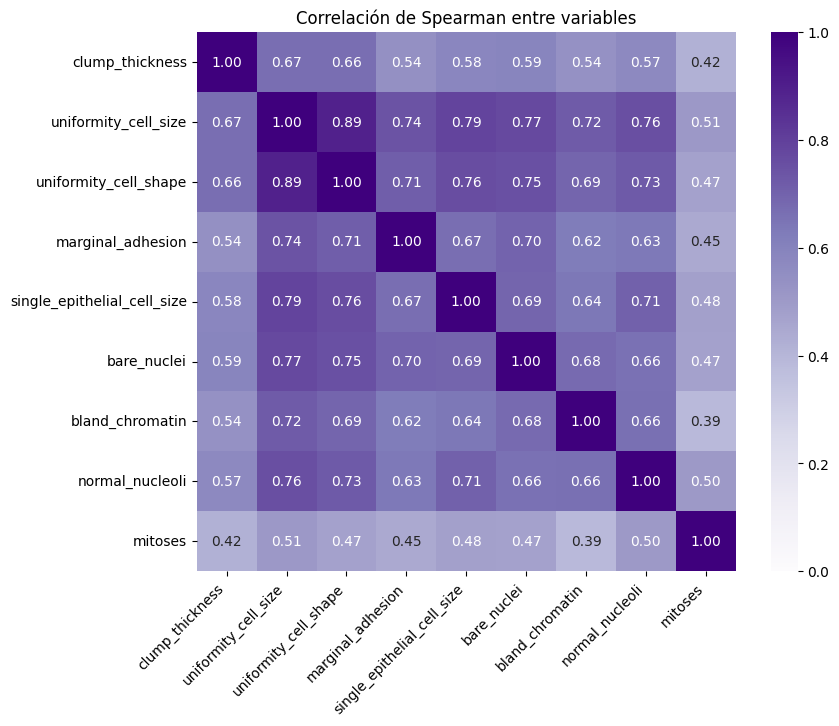

In [23]:
correlacion = df[variables_ordinales].corr(method="spearman")
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(correlacion, annot=True, fmt=".2f", cmap="Purples",
            vmin=0, vmax=1, square=True, ax=ax)
ax.set_title("Correlación de Spearman entre variables")
plt.xticks(rotation=45, ha="right")
plt.show()

Todas las correlaciones son positivas, cuando un atributo sube los demás también. La relación más alta es entre 'uniformity_cell_size' y 'uniformity_cell_shape' (0.89), que casi dan la misma información. La mayoría de las demás está entre 0.6 y 0.8. 'mitoses' es la menos relacionada con el resto (0.39 a 0.51), igual que en los boxplots, donde era la que menos separaba las clases.


---



**Técnica 1: limpieza**

1. Duplicados exactos: en la exploración se encontraron 8 parejas idénticas, incluido el id. Se elimina la segunda aparición de cada una.
2. Los id repetidos con valores distintos y los registros iguales sin considerar el id se conservan, porque todo indica que son muestras diferentes.

In [24]:
df_limpio = df.copy()

In [25]:
filas_antes = len(df_limpio)
df_limpio = df_limpio.drop_duplicates(keep="first")
print("Filas eliminadas:", filas_antes - len(df_limpio))
print("Dimensiones actuales:", df_limpio.shape)

Filas eliminadas: 8
Dimensiones actuales: (691, 11)


3. Columna id no aporta información para distinguir las clases y ya no se necesita para buscar duplicados, así que se elimina.

In [26]:
df_limpio = df_limpio.drop(columns="id")
print("Dimensiones actuales:", df_limpio.shape)

Dimensiones actuales: (691, 10)


4. Imputación de 'bare_nuclei'.

    Se usa KNNImputer, que busca los 5 registros más parecidos en los demás atributos y les asigna el promedio de su valor en 'bare_nuclei'. Se eligió por dos razones:

    a. En el análisis multivariado se vio que los atributos están correlacionados, así que los demás atributos dan buena información para estimar el faltante.

    b. Si la mediana de 'bare_nuclei' es 1 o valores bajos, imputar con ella le pondría valores bajos a los 16 registros, aunque alguno tenga valores altos en todo lo demás.

    La clase no se usa para imputar, para que el diagnóstico no influya en los atributos. Primero se marca qué registros eran faltantes.

In [27]:
from sklearn.impute import KNNImputer
df_limpio["bare_nuclei_era_faltante"] = df_limpio["bare_nuclei"].isna().astype(int)
faltantes = df_limpio["bare_nuclei_era_faltante"] == 1
imputador = KNNImputer(n_neighbors=5)
imputado = imputador.fit_transform(df_limpio[variables_ordinales])
imputado = pd.Series(
    np.round(imputado[:, variables_ordinales.index("bare_nuclei")]),
    index=df_limpio.index)
pd.DataFrame({
    "class": df_limpio.loc[faltantes, "class"],
    "valor_imputado": imputado[faltantes]})

,class,valor_imputado
23,4,7.0
40,2,8.0
139,2,1.0
145,2,1.0
158,2,1.0
164,2,1.0
235,2,1.0
249,2,1.0
275,2,1.0
292,4,6.0


A la mayoría se le asignó 1, pero no a todos. Los 2 malignos recibieron valores altos (7 y 6), coherente con lo visto en los boxplots. Dos benignos también recibieron valores altos (8 y 9), porque sus vecinos tenían valores altos en los demás atributos.

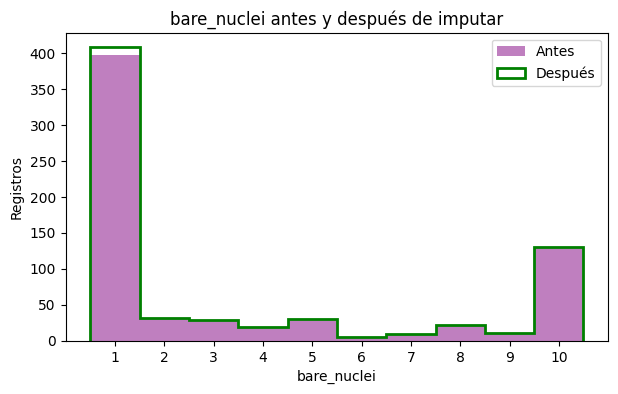

In [28]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df_limpio["bare_nuclei"].dropna(), bins=np.arange(0.5, 11.5, 1),
        color="purple", alpha=0.5, label="Antes")
ax.hist(imputado, bins=np.arange(0.5, 11.5, 1),
        histtype="step", color="green", linewidth=2, label="Después")
ax.set_xticks(range(1, 11))
ax.set_xlabel("bare_nuclei")
ax.set_ylabel("Registros")
ax.set_title("bare_nuclei antes y después de imputar")
ax.legend()
plt.show()

La forma de la distribución casi no cambia, porque solo se imputaron 16 de 691 valores. La diferencia se nota en el valor 1, donde la línea verde queda un poco por encima de la barra, porque ahí cayó la mayoría de los imputados (12). Los otros 4 quedaron en valores del 2 y del 6 al 9, uno en cada uno, y a esta escala no se alcanzan a ver. La imputación completó los datos sin alterar la distribución original.

In [29]:
df_limpio["bare_nuclei"] = imputado.astype(int)
print("Faltantes:", df_limpio["bare_nuclei"].isna().sum())
print("Tipo:", df_limpio["bare_nuclei"].dtype)

Faltantes: 0
Tipo: int64


5. Recodificación de la clase. Se cambia 2 → 0 (benigno) y 4 → 1 (maligno), que es la forma habitual de codificar una variable binaria.

In [30]:
df_limpio["class"] = df_limpio["class"].map({2: 0, 4: 1})
df_limpio["class"].value_counts()

,count
class,
0,453
1,238


In [31]:
reporte_final = pd.Series({
    "filas_originales": len(df),
    "filas_finales": len(df_limpio),
    "faltantes": int(df_limpio.isna().sum().sum()),
    "valores_fuera_de_rango": int((~df_limpio[variables_ordinales].isin(range(1, 11))).sum().sum()),
    "valores_de_clase": sorted(df_limpio["class"].unique()),
    "registros_iguales_conservados": int(df_limpio.drop(columns="bare_nuclei_era_faltante").duplicated().sum())
})
reporte_final.to_frame("resultado")

,resultado
filas_originales,699
filas_finales,691
faltantes,0
valores_fuera_de_rango,0
valores_de_clase,"[0, 1]"
registros_iguales_conservados,234


**Registro de decisiones**

| Problema | Tratamiento | Riesgo o limitación |
|---|---|---|
| Faltantes marcados con '?' | Conversión a NaN y columna a numérica | Ninguno, la documentación confirma que '?' es faltante |
| 8 duplicados exactos | Se elimina la segunda aparición | Si eran muestras distintas con el mismo id, se pierde información |
| id repetidos con valores distintos | Se conservan | No se sabe con certeza qué identifica el id |
| Registros iguales sin considerar id | Se conservan | Si alguno era un duplicado real, queda sobrerrepresentado |
| Columna id | Se elimina | Se pierde la posibilidad de agrupar muestras por paciente |
| 16 faltantes en bare_nuclei | Imputación con KNN (5 vecinos), redondeo y columna indicadora | El imputador se ajustó con todos los datos, antes de separar entrenamiento y prueba |
| Clase codificada como 2 y 4 | Recodificación a 0 y 1 | Ninguno |



---



**Técnica 2: Aumento de datos**

Después de la limpieza, las clases siguen desbalanceadas: 453 benignos y 238 malignos. El aumento se usa para balancearlas.

Primero se separan entrenamiento y prueba, y el aumento se aplica solo a entrenamiento.

In [32]:
from sklearn.model_selection import train_test_split
X = df_limpio[variables_ordinales]
y = df_limpio[variable_objetivo]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)
print("Entrenamiento:", y_train.value_counts().sort_index().to_dict())
print("Prueba:       ", y_test.value_counts().sort_index().to_dict())

Entrenamiento: {0: 317, 1: 166}
Prueba:        {0: 136, 1: 72}


Entrenamiento queda con 317 benignos y 166 malignos, y prueba con 136 y 72. Prueba ya no se modifica.

Para balancear las clases se prueba primero SMOTE, que crea registros malignos nuevos combinando malignos parecidos entre sí. En la exploración se vio que los malignos tienden a valores altos, así que los registros sintéticos deberían parecerse a ellos.

Se comparará la mediana de cada atributo entre los malignos originales y los sintéticos. Si los sintéticos quedan cargados hacia valores bajos, más parecidos a los benignos, se descarta SMOTE y se usa sobremuestreo aleatorio.

In [33]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
sinteticos = X_smote.iloc[len(X_train):]
sinteticos = sinteticos.round().clip(1, 10).astype(int)
print("Después de SMOTE:", y_smote.value_counts().sort_index().to_dict())
print("Registros sintéticos:", len(sinteticos))

Después de SMOTE: {0: 317, 1: 317}
Registros sintéticos: 151


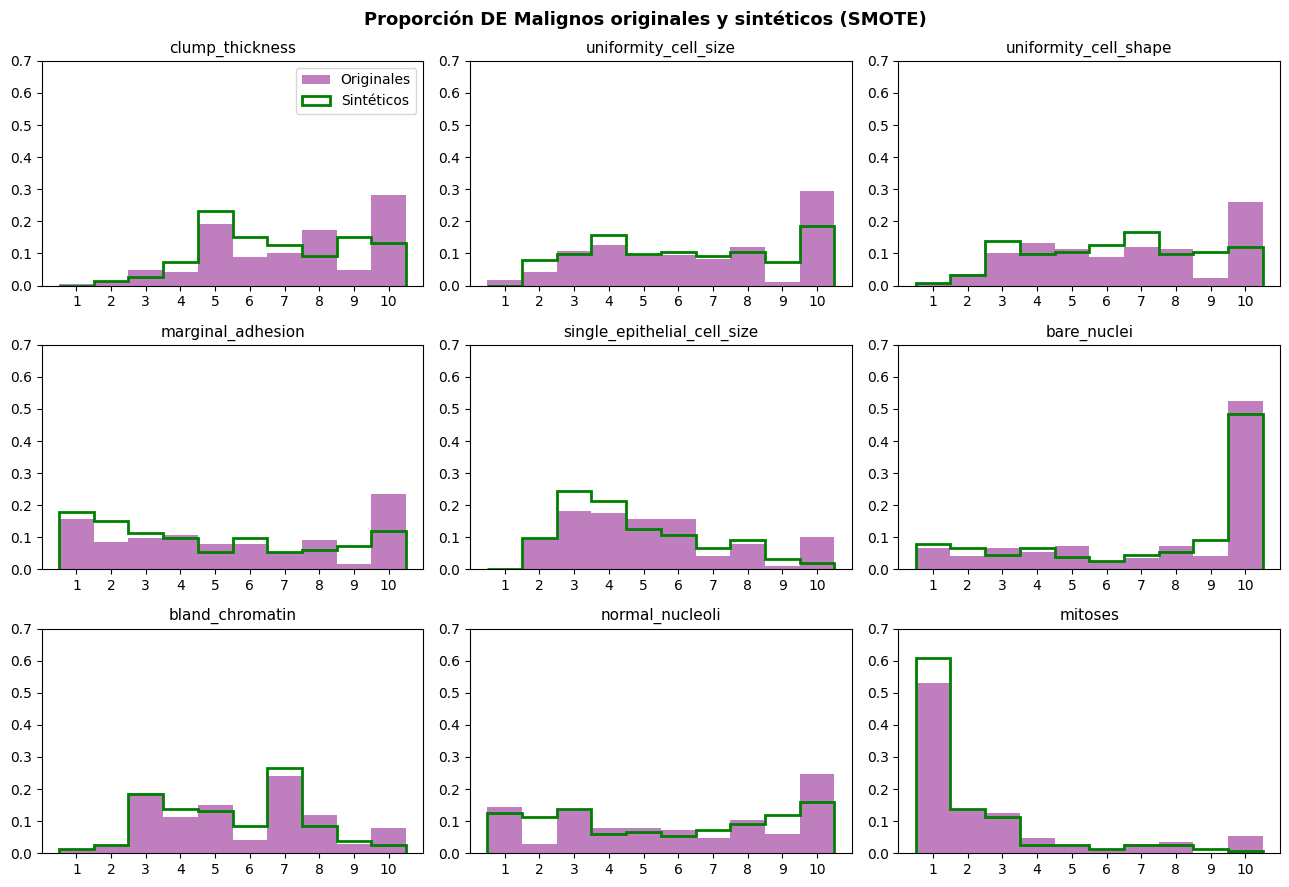

In [47]:
malignos_originales = X_train[y_train == 1]
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for ax, columna in zip(axes.ravel(), variables_ordinales):
    ax.hist(malignos_originales[columna], bins=np.arange(0.5, 11.5, 1),
            density=True, color="purple", alpha=0.5, label="Originales")
    ax.hist(sinteticos[columna], bins=np.arange(0.5, 11.5, 1),
            density=True, histtype="step", color="green", linewidth=2,
            label="Sintéticos")
    ax.set_title(columna, fontsize=11)
    ax.set_xticks(range(1, 11))
    ax.set_ylim(0, 0.7)
axes[0, 0].legend()
fig.suptitle("Proporción DE Malignos originales y sintéticos (SMOTE)",
             fontsize=13, color="black", fontweight="bold")
plt.tight_layout()
plt.show()

In [48]:
pd.DataFrame({
    "benignos": X_train[y_train == 0].median(),
    "malignos_originales": malignos_originales.median(),
    "sinteticos": sinteticos.median()
})

,benignos,malignos_originales,sinteticos
clump_thickness,3.0,8.0,7.0
uniformity_cell_size,1.0,7.0,6.0
uniformity_cell_shape,1.0,7.0,6.0
marginal_adhesion,1.0,5.0,4.0
single_epithelial_cell_size,2.0,5.0,4.0
bare_nuclei,1.0,10.0,9.0
bland_chromatin,2.0,6.0,6.0
normal_nucleoli,1.0,6.0,5.0
mitoses,1.0,1.0,1.0


Las medianas de los sintéticos quedan igual o un punto por debajo de las de los malignos originales, y lejos de las de los benignos. Por ejemplo, en 'bare_nuclei' los sintéticos tienen mediana 9, los malignos 10 y los benignos 1.

Los sintéticos no se cargan hacia valores bajos, así que se mantiene SMOTE.

Se arma el conjunto de entrenamiento aumentado con los registros originales y los sintéticos redondeados:

In [50]:
X_aumentado = X_smote.round().clip(1, 10).astype(int)
y_aumentado = y_smote
print("Dimensiones:", X_aumentado.shape)
print("Clases:", y_aumentado.value_counts().sort_index().to_dict())
print("Valores fuera de 1 a 10:", (~X_aumentado.isin(range(1, 11))).sum().sum())

Dimensiones: (634, 9)
Clases: {0: 317, 1: 317}
Valores fuera de 1 a 10: 0


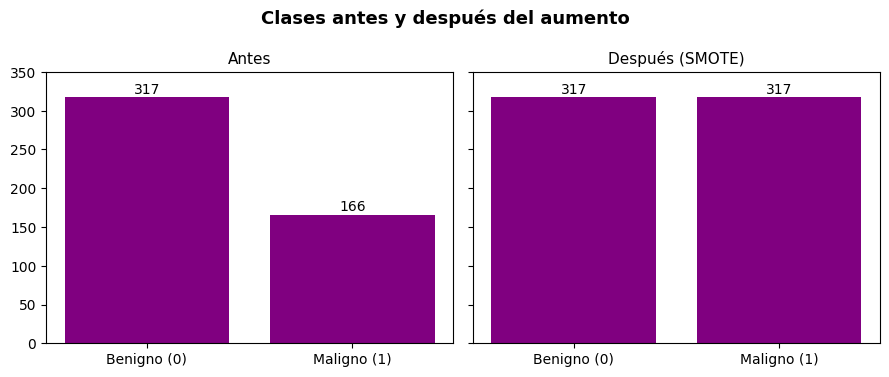

In [53]:
conteos = {
    "Antes": y_train.value_counts().sort_index(),
    "Después (SMOTE)": y_aumentado.value_counts().sort_index()
}
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)
for ax, (nombre, conteo) in zip(axes, conteos.items()):
    ax.bar(["Benigno (0)", "Maligno (1)"], conteo, color="purple")
    for i, valor in enumerate(conteo):
        ax.text(i, valor + 5, valor, ha="center")
    ax.set_title(nombre, fontsize=11)
    ax.set_ylim(0, 350)
fig.suptitle("Clases antes y después del aumento",
             fontsize=13, color="black", fontweight="bold")
plt.tight_layout()
plt.show()

**Conclusión**

En la exploración se encontró que los faltantes venían marcados con '?' en 'bare_nuclei', que había 8 duplicados exactos y que el id no identifica muestras únicas. Los atributos se cargan hacia valores bajos en los benignos y hacia valores altos en los malignos, y están correlacionados entre sí.

En la limpieza se eliminaron los duplicados exactos y la columna id, se imputaron los 16 faltantes con KNN y se recodificó la clase a 0 y 1. Quedaron 691 registros completos.

Para el aumento se separaron entrenamiento y prueba, y se aplicó SMOTE solo a entrenamiento. Los registros sintéticos conservaron la distribución de los malignos originales, y las clases quedaron balanceadas con 317 registros cada una.

**Declaración de uso de IA**

Este notebook fue elaborado con apoyo de Claude (Anthropic) para resolver dudas sobre código y redacción. La interpretación de los resultados y la revisión final son responsabilidad del autor.